# ENSF 444 Final Project: Customer Churn Prediction
### Group #: 21  
### Client: Auracole
### Name(s): Sahil B and Jibran S


The purpose of this project is to develop a machine learning pipeline to predict customer churn for Auracole. We compare three different models (Logistic Regression, Random Forest, and XGBoost) using a workflow that includes preprocessing, dimensionality reduction, and evaluation via ROC AUC.

Link to dataset: https://www.kaggle.com/competitions/playground-series-s6e3/overview

### Step 0: Import Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Validation Metrics
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

import warnings
warnings.filterwarnings('ignore')

### Step 1: Load Data
Load the training and testing datasets from the Kaggle Playground Series.

In [49]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Define target and features
target = 'Churn'
X = train_df.drop(columns=[target, 'id'])
y = train_df[target]

X_test_final = test_df.drop(columns=['id'])

print(f"Training data shape: {X.shape}")
X.head()

Training data shape: (594194, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


See distribution of the classes

In [50]:
#TODO: get count and percentages of target variable/classes in one table
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True)

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)



Class Counts:
Churn
No     460377
Yes    133817
Name: count, dtype: int64

Class Percentages:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


Visualizing the datasest

note: check out downsampling and up sampling before training the models

imblearn

1.   List item
2.   List item



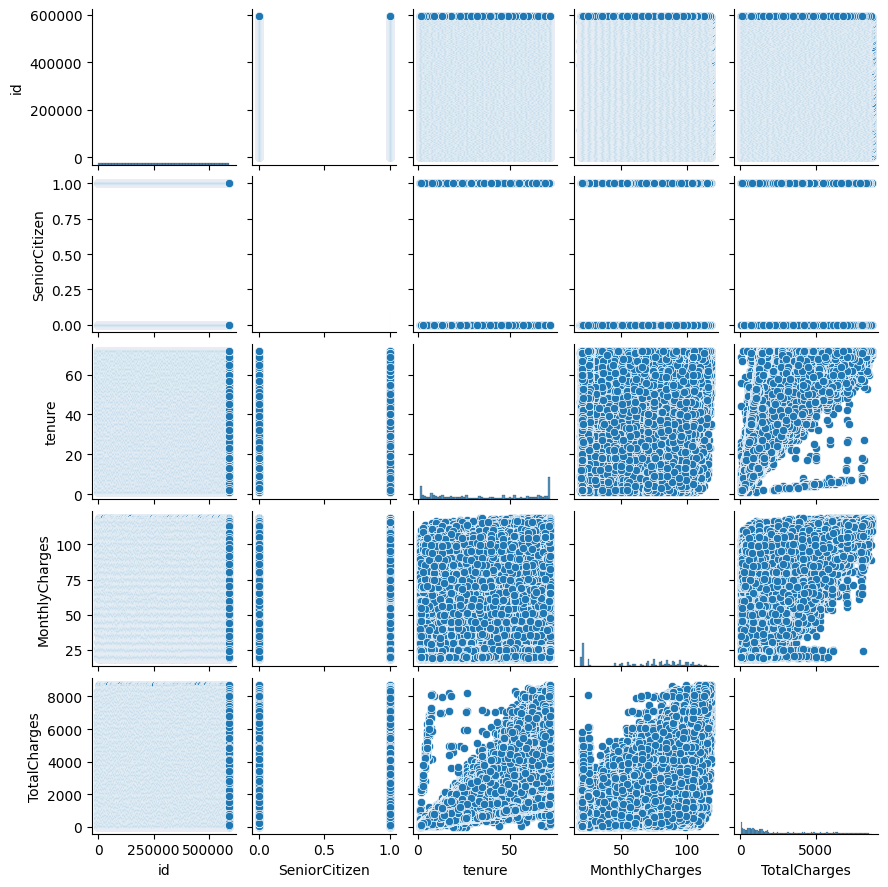

In [108]:
# Pairplot

sns.pairplot(train_df, height=1.8, aspect=1)
plt.show()

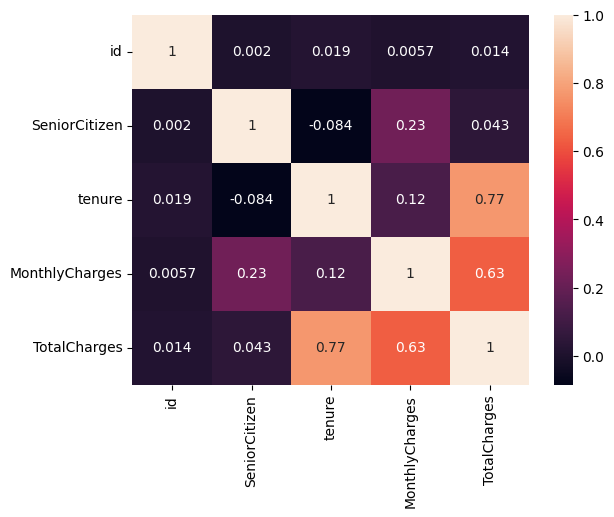

In [52]:
# Correalation plot

sns.heatmap(train_df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

### Step 2: Data Processing


Check to see if there are missing date in the dataset

In [53]:
X_missing = X.isna().sum().sum()
y_missing = y.isna().sum().sum()


print(f"Num missing in X: {X_missing}")
print(f"Num missing in y: {y_missing}")

Num missing in X: 0
Num missing in y: 0


In this step, we implement the preprocessing steps proposed: Standard Scaling for numerical data, One-Hot Encoding for categorical data, and PCA for dimensionality reduction.

In [ ]:
# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ])

# Just being extra careful to make sure there is in fact no NaN that make it through
non_nan_indices = y.dropna().index
X_cleaned = X.loc[non_nan_indices]
y_cleaned = y.loc[non_nan_indices]

# Convert 'No' and 'Yes' to 0 and 1 for the target variable
y_cleaned = y_cleaned.map({'No': 0, 'Yes': 1})

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned)

PCA compenents

Instead of explicitely specifying how many components for PCA, we instead elected to usse n_components < 1, which instead specifies the percentage of variance we want to retain. This is a more intuitive way to control the tradeoff between dimensionality reduction and information retention, and also allows us to automatically determine the number of components based on the data.


In [ ]:
# check how many pca components the data would get reduced to at n_components=0.90
pca = PCA(n_components=0.90)

# do the preprocessor before passing in X_train
X_train_transformed = preprocessor.fit_transform(X_train)
pca.fit(X_train_transformed)

print(f"NUmber of features in regular dataset: {len(X_train.columns)}")
print(f"Number of PCA components: {pca.n_components_}")



NUmber of features in regular dataset: 19
Number of PCA components: 14


### Step 3: ML Model Implementation
We initialize our three models: Logistic Regression (Baseline), Random Forest, and XGBoost.

In [94]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, device='cuda')
}

results = {}

### Step 3.1: Hyperparameter Tuning

In [95]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
# Using small grids for demonstration; for production, larger grids might be needed.
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, 20]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 500],
        'classifier__learning_rate': [0.05, 0.1]
    }
}

In [96]:
for name, model in models.items():
    print(f"Processing {name}...")

    # Create a base pipeline up to the classifier
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.90)),
        ('classifier', model)
    ])

    if name in param_grids:
        print(f"  Performing Grid Search for {name}...")
        # Use GridSearchCV to find the best hyperparameters
        grid_search = GridSearchCV(base_pipeline, param_grids[name], cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)

        best_pipeline = grid_search.best_estimator_
        y_pred_proba = best_pipeline.predict_proba(X_val)[:, 1]

        # Score the best estimator
        auc = roc_auc_score(y_val, y_pred_proba)
        fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

        results[name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr, 'pipeline': best_pipeline, 'best_params': grid_search.best_params_}
        print(f"  {name} Best Params: {grid_search.best_params_}")
        print(f"  {name} ROC AUC (tuned): {auc:.4f}")
    else:
        # Fit and Predict for models not undergoing Grid Search
        base_pipeline.fit(X_train, y_train)
        y_pred_proba = base_pipeline.predict_proba(X_val)[:, 1]

        # Score the model
        auc = roc_auc_score(y_val, y_pred_proba)
        fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

        results[name] = {'auc': auc, 'fpr': fpr, 'tpr': tpr, 'pipeline': base_pipeline}
        print(f"  {name} ROC AUC: {auc:.4f}")

Processing Logistic Regression...
  Performing Grid Search for Logistic Regression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Logistic Regression Best Params: {'classifier__C': 0.01}
  Logistic Regression ROC AUC (tuned): 0.9048
Processing Random Forest...
  Performing Grid Search for Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Random Forest Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
  Random Forest ROC AUC (tuned): 0.9082
Processing XGBoost...
  Performing Grid Search for XGBoost...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  XGBoost Best Params: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 500}
  XGBoost ROC AUC (tuned): 0.9106


### Step 4: Validation and Metrics
We train each model using a Pipeline and evaluate the performance using the Area Under the ROC Curve (AUC).

In [97]:
import time

for name, model in models.items():
    # Create full pipeline with PCA
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.90)),
        ('classifier', model)
    ])

    # Measure training time
    start_time = time.time()
    clf.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    # Predict
    y_pred_proba = clf.predict_proba(X_val)[:, 1]

    # Score
    auc = roc_auc_score(y_val, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

    results[name] = {
        'auc': auc,
        'fpr': fpr,
        'tpr': tpr,
        'pipeline': clf,
        'train_time': train_time
    }

    print(f"{name} ROC AUC: {auc:.4f} | Train Time: {train_time:.2f} sec")

Logistic Regression ROC AUC: 0.9048 | Train Time: 2.19 sec
Random Forest ROC AUC: 0.8866 | Train Time: 31.85 sec
XGBoost ROC AUC: 0.9095 | Train Time: 2.65 sec


In [102]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from IPython.display import display

# Fictional aurocole client hypothetical needs for balancing predictive performance and speed
roc_auc_weight = 0.90
speed_weight = 0.1

# --- Evaluate and Compare All Models ---
comparison_data = []



for name, result in results.items():
    best_model = result['pipeline']
    
    # --- Prediction timing (averaged over multiple runs) ---
    n_runs = 5 
    
    total_time = 0
    for _ in range(n_runs):
        start_time = time.perf_counter()
        y_pred = best_model.predict(X_val)
        y_pred_proba = best_model.predict_proba(X_val)[:, 1]
        total_time += (time.perf_counter() - start_time)
    
    pred_time = total_time / n_runs
    
    pred_time_per_sample = pred_time / len(X_val)
    
    # --- Metrics ---
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': auc,
        'Train Time (s)': result.get('train_time', None),
        'Predict Time (s)': pred_time,
        'Predict Time / Sample (ms)': pred_time_per_sample * 1000
    })

# --- DataFrame ---
comparison_df = pd.DataFrame(comparison_data).set_index('Model')

# --- Normalize Predict Time (lower is better --> invert it) ---
max_time = comparison_df['Predict Time (s)'].max()
comparison_df['Speed Score'] = 1 - (comparison_df['Predict Time (s)'] / max_time)

# --- Weighted Score (Client Criteria) ---
comparison_df['Final Score'] = (
    roc_auc_weight * comparison_df['ROC AUC'] +
    speed_weight * comparison_df['Speed Score']
)

# Sort by final score (not just ROC AUC anymore)
comparison_df = comparison_df.sort_values(by='Final Score', ascending=False)

print("=== Final Metrics Summary Table ===")


display(comparison_df)

# --- Best model ---
best_model_name = comparison_df.index[0]
best_row = comparison_df.iloc[0]

print("\n=== Conclusion ===")
print(
    f"{best_model_name} is the best model based on the client's criteria.\n\n"
    f"It achieved a ROC AUC of {best_row['ROC AUC']:.4f}, indicating strong predictive performance, "
    f"while also maintaining a fast prediction time of {best_row['Predict Time (s)']:.4f} seconds.\n\n"
    f"Using the weighted scoring system ({roc_auc_weight*100}% ROC AUC, {speed_weight*100}% prediction speed), "
    f"this model outperformed the others by offering the best balance between accuracy and efficiency."
)

=== Final Metrics Summary Table ===


,Accuracy,Precision,Recall,F1-Score,ROC AUC,Train Time (s),Predict Time (s),Predict Time / Sample (ms),Speed Score,Final Score
Model,,,,,,,,,,
Logistic Regression,0.852422,0.684833,0.638568,0.660892,0.904831,2.189046,0.566440,0.004766,0.585351,0.872883
XGBoost,0.854576,0.695412,0.630348,0.661283,0.909539,2.651918,0.654215,0.005505,0.521097,0.870695
Random Forest,0.838639,0.658293,0.589471,0.621984,0.886591,31.854666,1.366071,0.011495,0.000000,0.797932



=== Conclusion ===
Logistic Regression is the best model based on the client's criteria.

It achieved a ROC AUC of 0.9048, indicating strong predictive performance, while also maintaining a fast prediction time of 0.5664 seconds.

Using the weighted scoring system (90.0% ROC AUC, 10.0% prediction speed), this model outperformed the others by offering the best balance between accuracy and efficiency.


### Step 5: Visualization of Results
Visualize the performance comparison using ROC Curves.

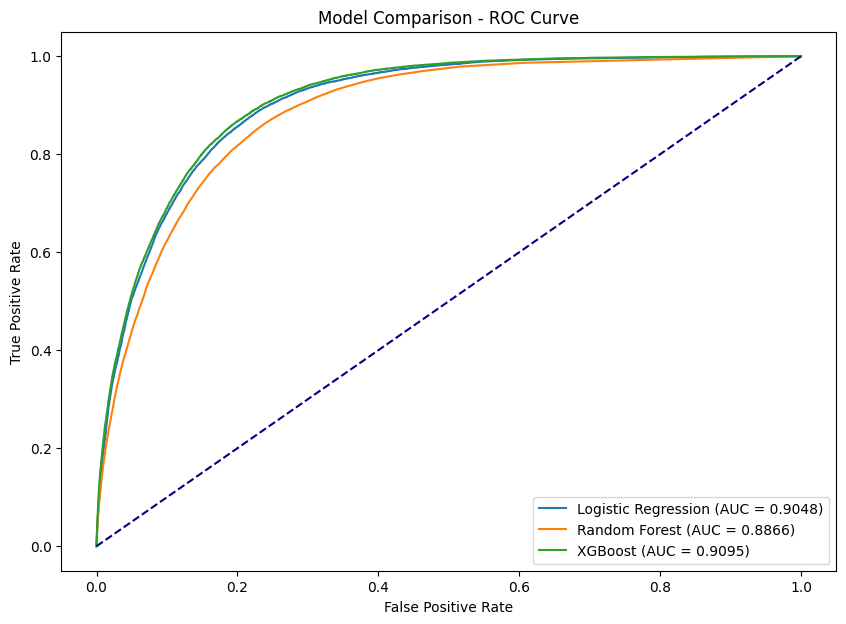

In [103]:
plt.figure(figsize=(10, 7))
for name, m in results.items():
    plt.plot(m['fpr'], m['tpr'], label=f"{name} (AUC = {m['auc']:.4f})")

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison - ROC Curve')
plt.legend(loc="lower right")
plt.show()

### Step 5.1: Confusion Matrix Visualization

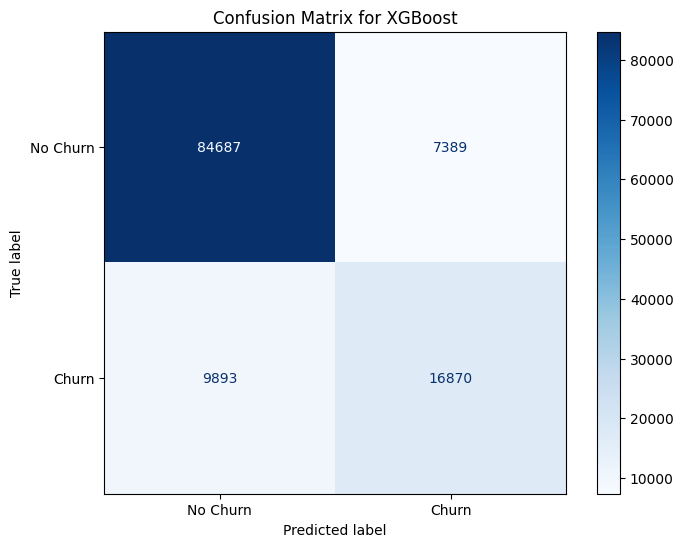

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the best model pipeline (after tuning, if applicable)
best_model_name_for_cm = max(results, key=lambda k: results[k]['auc'])
best_pipeline_for_cm = results[best_model_name_for_cm]['pipeline']

# Predict classes for the validation set
y_pred_val = best_pipeline_for_cm.predict(X_val)

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_val, labels=[0, 1])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix for {best_model_name_for_cm}')
plt.grid(False) # Turn off grid for confusion matrix
plt.show()

## Ethical Considerations



Checking model performance over subgroups to check if there is any bias. 

In [ ]:
# Analyze performance by subgroups (Gender and Senior Citizen status)
best_model = results[max(results, key=lambda k: results[k]['auc'])]['pipeline']

# Add the subgroups back to the validation set for analysis
X_val_analysis = X_val.copy()
X_val_analysis['y_true'] = y_val
X_val_analysis['y_prob'] = best_model.predict_proba(X_val)[:, 1]

def print_subgroup_auc(df, column_name):
    print(f"--- ROC AUC by {column_name} ---")
    for value in df[column_name].unique():
        subset = df[df[column_name] == value]
        if len(subset['y_true'].unique()) > 1:
            auc = roc_auc_score(subset['y_true'], subset['y_prob'])
            print(f"{value}: {auc:.4f} (n={len(subset)})")
        else:
            print(f"{value}: Not enough class diversity to calculate AUC.")
    print("\n")

# Calculate for SeniorCitizen and gender
print_subgroup_auc(X_val_analysis, 'SeniorCitizen')
print_subgroup_auc(X_val_analysis, 'gender')

--- ROC AUC by SeniorCitizen ---
0: 0.9103 (n=105213)
1: 0.8372 (n=13626)


--- ROC AUC by gender ---
Female: 0.9099 (n=59811)
Male: 0.9091 (n=59028)




### Step 6: Final Submission
Generate the submission file for Kaggle using the best performing model.

In [105]:
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_pipeline = results[best_model_name]['pipeline']

final_predictions = best_pipeline.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': final_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Submission created using {best_model_name}.")

Submission created using XGBoost.
